# 03 - Spatial (S) Metric Grounding & Centroid Localization
Specialized notebook for Stage 3 (Spatial grounding) experiments: optical-flow weighted centroid fallback, spatial feature EDA, and component score breakdown.


In [ ]:
# --- Setup & Load Core Pipeline Baseline ---
import sys, os
sys.path.append('../core')
# Load baseline model loading, track kinematics, evaluation scoring & core pipeline
if os.path.exists('../core/shared_pipeline.py'):
    %run ../core/shared_pipeline.py
else:
    print('shared_pipeline.py not found in ../core/! Please check repository structure.')


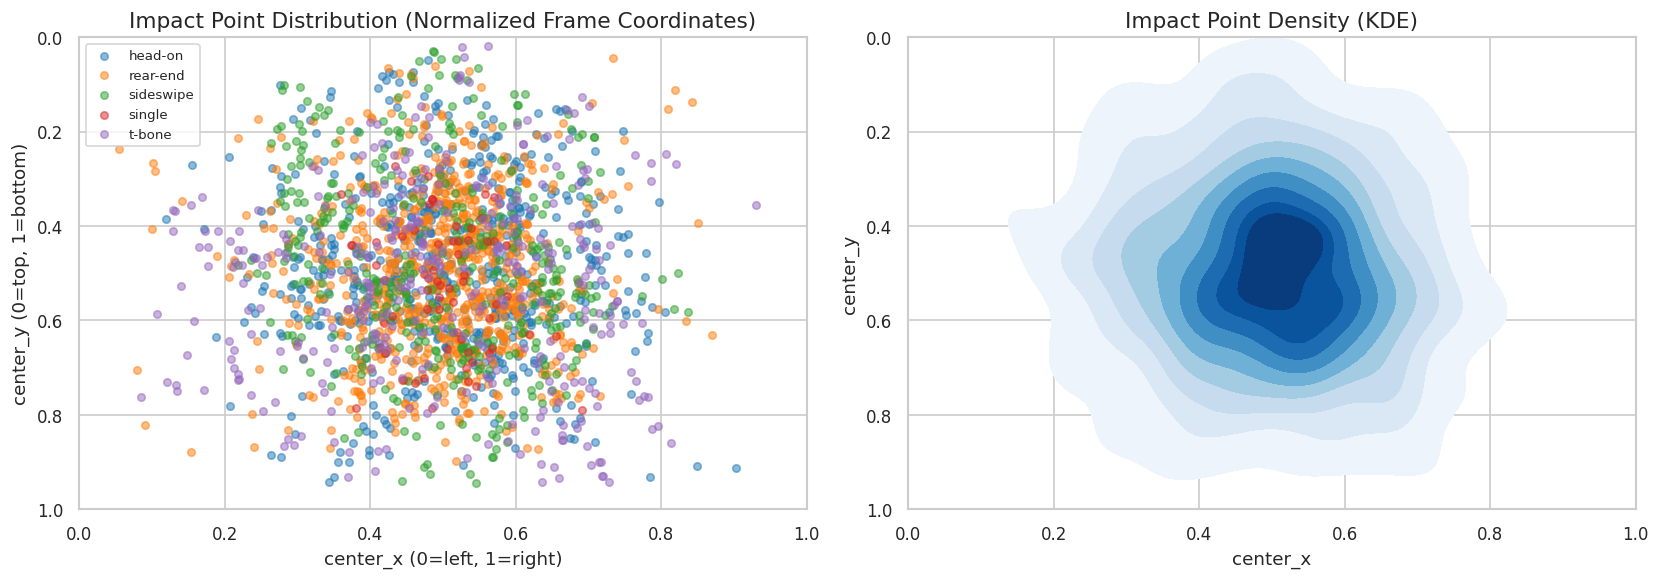

In [20]:
# [EDA] Spatial distribution of impact points -- 2D scatter and KDE
if not labels_clean.empty and all(c in labels_clean.columns for c in ['center_x', 'center_y']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for t_idx, (t_name, group) in enumerate(labels_clean.groupby('type')):
        axes[0].scatter(group['center_x'], group['center_y'],
                        label=t_name, alpha=0.5, s=20,
                        color=list(PALETTE.values())[t_idx % len(PALETTE)])
    axes[0].legend(fontsize=8)
    axes[0].set_title('Impact Point Distribution (Normalized Frame Coordinates)')
    axes[0].set_xlabel('center_x (0=left, 1=right)')
    axes[0].set_ylabel('center_y (0=top, 1=bottom)')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].invert_yaxis()  # match image coordinate convention

    sns.kdeplot(data=labels_clean, x='center_x', y='center_y',
                fill=True, cmap='Blues', ax=axes[1])
    axes[1].set_title('Impact Point Density (KDE)')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

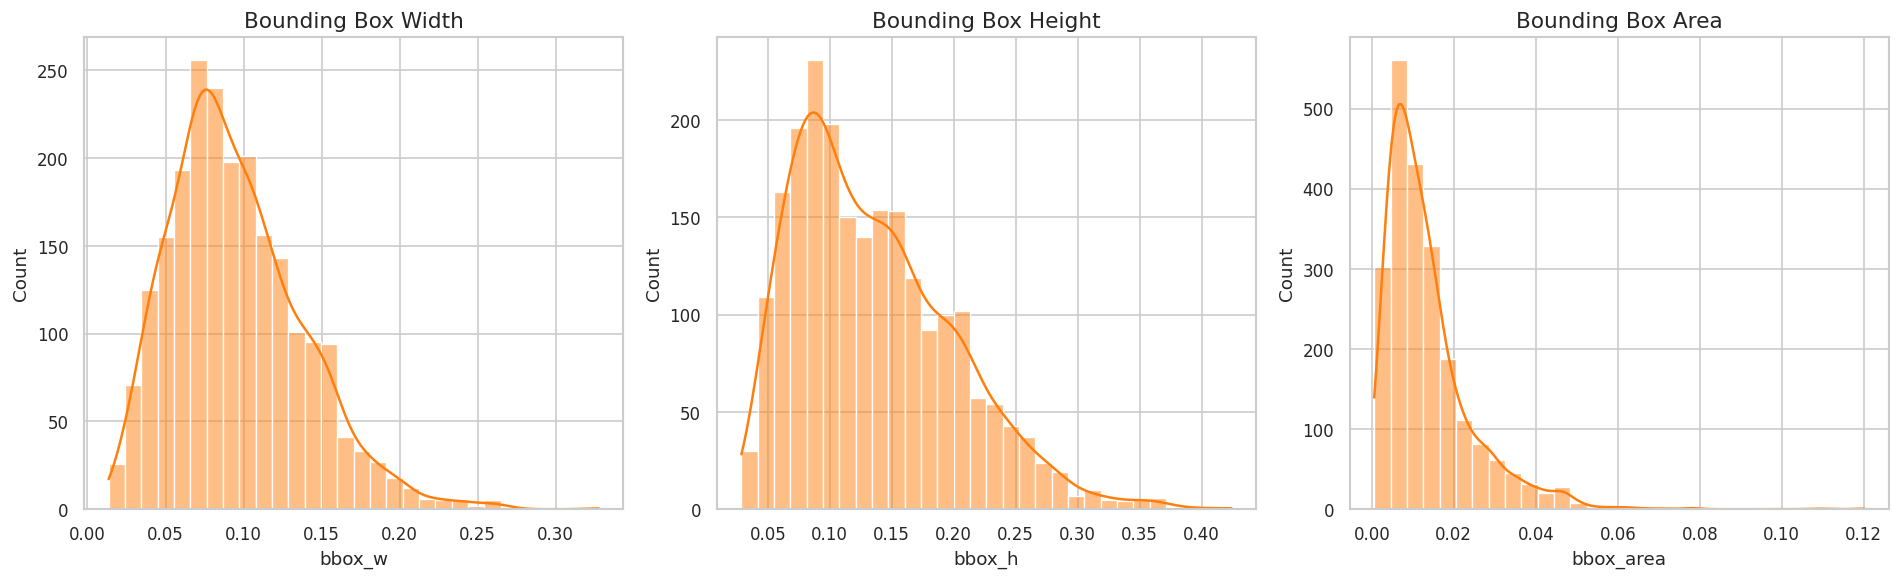

In [21]:
# [EDA] Bounding box size distributions
if not labels_clean.empty and all(c in labels_clean.columns for c in ['x1', 'y1', 'x2', 'y2']):
    labels_clean['bbox_w']    = labels_clean['x2'] - labels_clean['x1']
    labels_clean['bbox_h']    = labels_clean['y2'] - labels_clean['y1']
    labels_clean['bbox_area'] = labels_clean['bbox_w'] * labels_clean['bbox_h']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, title in zip(
        axes,
        ['bbox_w', 'bbox_h', 'bbox_area'],
        ['Bounding Box Width', 'Bounding Box Height', 'Bounding Box Area'],
    ):
        sns.histplot(labels_clean[col], bins=30, kde=True, color=PALETTE['secondary'], ax=ax)
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

In [27]:
# [FEATURE] Optical-flow magnitude map -- spatial localization signal

def compute_flow_magnitude_map(video_path: pathlib.Path,
                               resize_w: int = 320,
                               resize_h: int = 180,
                               n_frames_context: int = 30,
                               center_frame: int = None,
                               flow_percentile: float = 90.0) -> np.ndarray:
    """Cumulative Farneback optical-flow magnitude over a window of frames
    centered on center_frame, with percentile thresholding to suppress
    background motion. Returns a 2D array of shape (resize_h, resize_w).
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if center_frame is not None:
        start_frame = max(0, center_frame - n_frames_context // 2)
    else:
        start_frame = max(0, total // 3)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    mag_accum = np.zeros((resize_h, resize_w), dtype=np.float32)
    prev_gray, count = None, 0

    while count < n_frames_context:
        ret, frame = cap.read()
        if not ret:
            break
        frame_small = cv2.resize(frame, (resize_w, resize_h))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)
        if prev_gray is not None:
            flow = cv2.calcOpticalFlowFarneback(
                prev_gray, gray, None,
                pyr_scale=0.5, levels=3, winsize=15,
                iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
            mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
            mag_accum += mag
        prev_gray = gray
        count += 1

    cap.release()

    if mag_accum.max() > 0:
        thresh = np.percentile(mag_accum, flow_percentile)
        mag_accum[mag_accum < thresh] = 0.0

    return mag_accum


print('[STATUS] compute_flow_magnitude_map defined')

[STATUS] compute_flow_magnitude_map defined


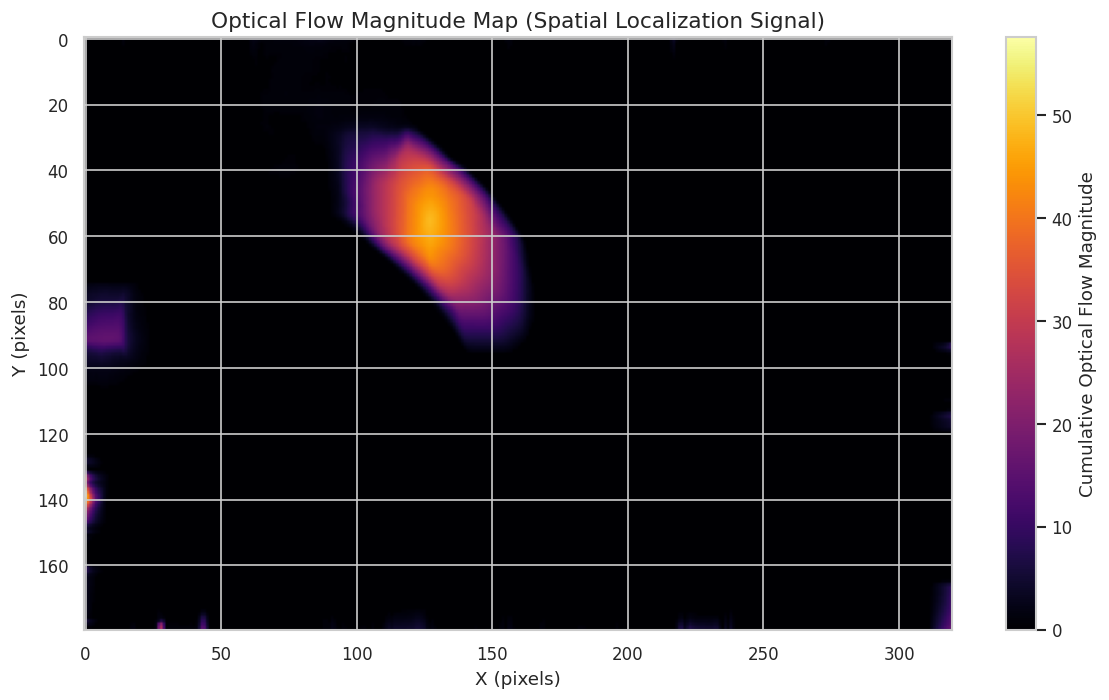

In [30]:
# [FEATURE] Visualize optical-flow magnitude map for a synthetic sample
if synthetic_videos:
    flow_map = compute_flow_magnitude_map(synthetic_videos[0])

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(flow_map, cmap='inferno', aspect='auto')
    plt.colorbar(im, ax=ax, label='Cumulative Optical Flow Magnitude')
    ax.set_title('Optical Flow Magnitude Map (Spatial Localization Signal)')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    plt.tight_layout()
    plt.show()
else:
    print('[STATUS] No synthetic videos -- skipping flow map visualization')

### 6.6 Stage 3 -- Where: Impact Point Localization (fallback chain)

> **Correction -- OWLv2 grounding described below is removed from the pipeline.** `run_inference_baseline` calls `predict_impact_location_flow` (optical-flow centroid) directly; `predict_impact_location_grounded` was never wired into any pipeline that is actually called and has been deleted from the notebook. Section 7b measured OWLv2/optical-flow at S=0.156 against a constant's 0.216 -- it lost. Kept as a documented negative result.

When tracking is trusted, the impact point is the box-intersection centroid from Section 6.3 -- it answers "where did these two vehicles touch" directly. Otherwise the optical-flow weighted centroid is used -- a real motion-based estimate rather than the uninformative frame center.


In [41]:
# [MODEL] Stage 3a -- optical-flow weighted centroid (last-resort spatial signal)

def predict_impact_location_flow(video_path: pathlib.Path,
                                 accident_time: float = None,
                                 n_frames_context: int = 30) -> tuple:
    """Normalized (center_x, center_y) as the weighted centroid of the
    cumulative optical-flow magnitude map centered on the accident time.
    """
    RESIZE_W, RESIZE_H = 320, 180

    center_frame = None
    if accident_time is not None:
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        if fps > 0:
            center_frame = int(accident_time * fps)

    mag_map = compute_flow_magnitude_map(
        video_path, resize_w=RESIZE_W, resize_h=RESIZE_H,
        n_frames_context=n_frames_context, center_frame=center_frame,
    )

    total_mag = mag_map.sum()
    if total_mag < 1e-6:
        return 0.5, 0.5  # no motion detected anywhere

    ys, xs = np.mgrid[0:RESIZE_H, 0:RESIZE_W]
    cx = float((xs * mag_map).sum() / total_mag) / RESIZE_W
    cy = float((ys * mag_map).sum() / total_mag) / RESIZE_H
    return round(cx, 6), round(cy, 6)


print('[STATUS] predict_impact_location_flow defined')

[STATUS] predict_impact_location_flow defined


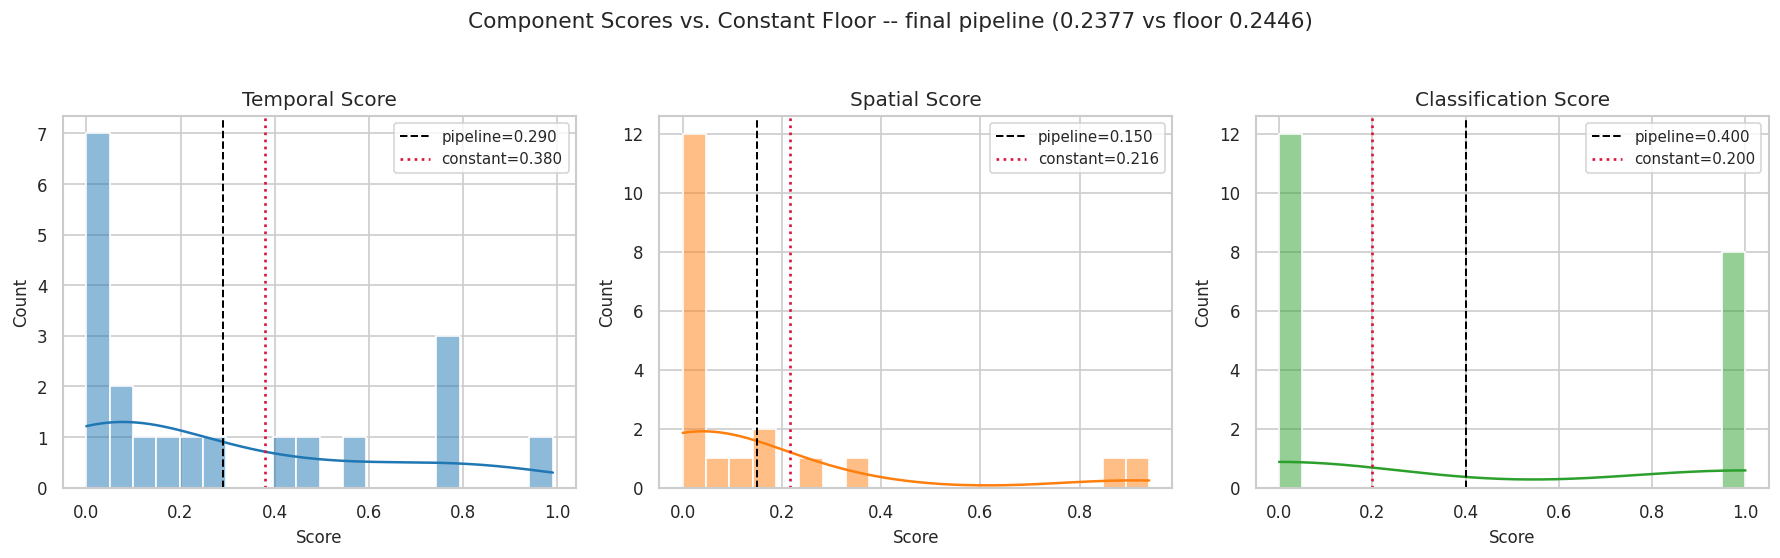

In [63]:
# [EVAL] Component score distributions vs. the constant floor -- final pipeline
if not eval_final.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    score_cols  = ['T', 'S', 'C']
    score_names = ['Temporal Score', 'Spatial Score', 'Classification Score']
    colors      = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary']]

    for ax, col, name, color in zip(axes, score_cols, score_names, colors):
        sns.histplot(eval_final[col], bins=20, kde=True, color=color, ax=ax)
        ax.axvline(eval_final[col].mean(), linestyle='--', color='black',
                   linewidth=1.2, label=f'pipeline={eval_final[col].mean():.3f}')
        ax.axvline(const_eval[col].mean(), linestyle=':', color='crimson',
                   linewidth=1.6, label=f'constant={const_eval[col].mean():.3f}')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Score', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.legend(fontsize=9)

    plt.suptitle(f'Component Scores vs. Constant Floor -- final pipeline '
                 f'({accident_score(eval_final):.4f} vs floor {accident_score(const_eval):.4f})',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()